# 🎵 Music Generation Using Recurrent Neural Networks (RNN)
### Student Laboratory Notebook

---

| Field | Details |
|-------|---------|
| **Course** | Deep Learning Lab |
| **Topic** | Sequence Modelling — Music Generation with RNN |
| **Dataset** | MIDI Music Files (Nottingham / Custom) |
| **Framework** | TensorFlow / Keras |
| **Notation** | Prof. Mitesh Khapra (CS7015, IIT Madras) |

---

## 📌 Objective

In this experiment you will:
1. Understand how music can be represented as a **sequence of discrete tokens** (notes/chords)
2. Build a **character-level RNN** that learns musical patterns
3. Train the model to **generate new music sequences** note by note
4. Analyse the effect of **temperature (τ)** on creativity vs coherence
5. Optionally convert generated sequences back to **playable MIDI audio**

---

## 📐 Notation Reference (Mitesh Khapra, CS7015)

| Symbol | Meaning |
|--------|---------|
| $x_t$ | Input token (note/chord) at time step $t$ |
| $s_t$ | Hidden state at time $t$ |
| $W$ | Input-to-hidden weight matrix |
| $U$ | Hidden-to-hidden (recurrent) weight matrix |
| $V$ | Hidden-to-output weight matrix |
| $b_s$, $b_y$ | Bias vectors |
| $\hat{y}_t$ | Predicted output distribution over notes |
| $\tau$ | Temperature for sampling |

**RNN Equations:**
$$s_t = \tanh(W \cdot x_t + U \cdot s_{t-1} + b_s)$$
$$\hat{y}_t = \text{softmax}(V \cdot s_t + b_y)$$

---

## ⚠️ Instructions to Students

- **Do NOT modify** the section headings or question cells.
- Fill in all cells marked with `# YOUR CODE HERE` or `# YOUR ANSWER HERE`.
- Answer all written questions in the **Markdown Answer cells** provided below each question.
- Run cells **in order** from top to bottom.
- Save your completed notebook as: `RollNumber_MusicGen_RNN.ipynb`

---

---
# 📦 Section 1: Environment Setup & Library Imports
---

### 🔷 Background

Before building any model, we must prepare our Python environment. For music generation we need:
- `music21` — a toolkit for parsing and writing MIDI files
- `tensorflow` / `keras` — for building and training the RNN
- `numpy`, `matplotlib` — for data manipulation and visualisation

> **MIDI (Musical Instrument Digital Interface):** A standard protocol that represents music as a sequence of events — notes, durations, velocities — rather than raw audio. Each note can be encoded as an integer, making MIDI ideal for sequence modelling.

In [ ]:
# Install required libraries (run once)
!pip install music21 --quiet

In [ ]:
# ── Standard imports ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import os, glob, pickle

# ── Deep learning ────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Music processing ─────────────────────────────────────────
from music21 import converter, instrument, note, chord, stream

print("TensorFlow :", tf.__version__)
print("All libraries loaded successfully ✓")

TensorFlow : 2.19.0
All libraries loaded successfully ✓


### ❓ Question 1.1 — Conceptual Understanding

**Why is MIDI a better representation for music generation with an RNN compared to raw audio (WAV/MP3)?  
Discuss in terms of sequence length, vocabulary size, and computational cost.**

> 💡 *Hint: Think about the sampling rate of audio (44,100 samples/sec) vs the number of discrete MIDI note events per second.*

**✏️ Your Answer:**

MIDI is a far better representation for music generation with an RNN compared to raw audio (WAV/MP3) due to several key factors:

1.  **Sequence Length:**
    *   **Raw Audio:** Raw audio files (like WAV/MP3) represent sound as continuous waveforms sampled at very high frequencies (e.g., 44,100 samples/second for CD quality). This means a short piece of music (e.g., 10 seconds) would result in a sequence of 441,000 samples. An RNN trying to learn patterns from such a long sequence would face extreme computational challenges and the vanishing/exploding gradient problem, making it difficult to capture long-term dependencies.
    *   **MIDI:** MIDI represents music as a series of discrete events (note on/off, pitch, velocity, duration). A 10-second piece of music might only have a few dozen to a couple of hundred MIDI events. This results in much shorter and more manageable sequences for an RNN, allowing it to capture musical structure and dependencies over meaningful musical phrases.

2.  **Vocabulary Size:**
    *   **Raw Audio:** The 'vocabulary' for raw audio is essentially the range of possible amplitude values, which can be very large (e.g., 65,536 values for 16-bit audio). While often binned or quantized, the continuous nature makes a discrete vocabulary difficult and extensive.
    *   **MIDI:** The vocabulary for MIDI is much smaller and more constrained. It consists of specific notes (typically 128 MIDI notes, with variations for chords, rests, and instrument changes). This finite and relatively small vocabulary makes it feasible for an RNN to predict the next 'token' (note or chord) as a classification task over a limited set of possibilities.

3.  **Computational Cost:**
    *   **Raw Audio:** The extremely long sequences and large effective vocabulary of raw audio lead to astronomical computational costs for training an RNN. Processing hundreds of thousands of samples per second, learning features from continuous waveforms, and predicting over a vast output space requires immense processing power and memory, making it impractical for typical RNN architectures.
    *   **MIDI:** With significantly shorter sequences and a small, discrete vocabulary, the computational cost for training and inference with MIDI data is drastically reduced. RNNs can effectively learn the relationships between notes and chords, making music generation a tractable problem within reasonable computational limits.

---
# 🎼 Section 2: Dataset Loading & MIDI Parsing
---

### 🔷 Background

We use the **Nottingham Music Dataset** — a collection of 1,000+ folk tunes in MIDI format.  
You can also use your own MIDI files.

Each MIDI file is parsed into a flat list of **note/chord strings**, for example:

```
['C4', 'E4', 'G4', 'E.G.C5', 'D4', 'F4', ...]
```

Where:
- `'C4'` = single note C in octave 4
- `'E.G.C5'` = chord containing notes E, G, C5 (dot-separated)

**Dataset Download:**  
Place your `.mid` files inside a folder called `midi_songs/` in your working directory.  
Or use the Nottingham dataset: https://github.com/jukedeck/nottingham-dataset

In [ ]:
!unzip nottingham-dataset-master.zip

Archive:  nottingham-dataset-master.zip
0992bb6cd864f6d4b90d6663e08c0ef53ffaa08f
   creating: nottingham-dataset-master/
 extracting: nottingham-dataset-master/.gitignore  
   creating: nottingham-dataset-master/ABC_cleaned/
  inflating: nottingham-dataset-master/ABC_cleaned/ashover.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/hpps.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/jigs.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/morris.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/playford.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/reelsa-c.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/reelsd-g.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/reelsh-l.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/reelsm-q.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/reelsr-t.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/reelsu-z.abc  
  inflating: nottingham-dataset-master/ABC_cleaned/slip.abc 

In [ ]:
def parse_midi_files(midi_folder: str) -> list:
    """
    Parse all MIDI files in a folder and extract notes/chords.

    Args:
        midi_folder : path to folder containing .mid files

    Returns:
        notes : flat list of note/chord strings
    """
    notes = []
    midi_files = glob.glob(os.path.join(midi_folder, "*.mid"))

    print(f"Found {len(midi_files)} MIDI files.")

    for file in midi_files:
        try:
            midi = converter.parse(file)
            parts = instrument.partitionByInstrument(midi)
            elements = parts.parts[0].recurse() if parts else midi.flat.notes

            for element in elements:
                if isinstance(element, note.Note):
                    notes.append(str(element.pitch))
                elif isinstance(element, chord.Chord):
                    notes.append(".".join(str(n) for n in element.normalOrder))
        except Exception as e:
            print(f"  Skipping {file}: {e}")

    print(f"Total notes/chords extracted: {len(notes):,}")
    return notes


# ── Load notes ───────────────────────────────────────────────
# TODO: Replace 'midi_songs/' with your actual folder path
MIDI_FOLDER = "nottingham-dataset-master/MIDI/"
notes = parse_midi_files(MIDI_FOLDER)

# Preview
print(f"\nFirst 20 tokens: {notes[:20]}")

Found 1034 MIDI files.
Total notes/chords extracted: 248,464

First 20 tokens: ['D5', 'G5', '7.11.2', 'D5', 'B4', 'D5', 'B4', 'G4', '7.11.2', 'G4', 'G4', 'A4', 'B4', 'C5', '0.4.7', 'B4', 'A4', 'G4', 'G4', '9.0.4']


### ❓ Question 2.1 — Data Exploration

**After parsing your MIDI files, answer the following:**

1. How many unique notes/chords are in your dataset? (This is your vocabulary size $|\mathcal{V}|$)


2. What is the total sequence length $N$?
3. List the **5 most frequent** notes/chords in your dataset.
4. Why does vocabulary size $|\mathcal{V}|$ matter for the RNN's output layer?

> 💡 *Use Python's `collections.Counter` to find frequencies.*

Answers

1. The dataset contains 130 unique notes/chords, so the vocabulary size is |V| = 130.

2. The total sequence length is N = 248,464.

3. The 5 most frequent notes/chords are:  
   D5 → 27,554 times  
   A4 → 26,388 times  
   B4 → 23,517 times  
   E5 → 20,481 times  
   G4 → 15,812 times  

4. The vocabulary size determines the number of neurons in the RNN’s output layer. Each neuron represents one possible note or chord, and the model predicts probabilities over all of them using softmax. A larger vocabulary increases model complexity, computation, and makes training more difficult.

In [ ]:
from collections import Counter

# 1. Vocabulary size
vocab_size = len(set(notes))

# 2. Total sequence length
N = len(notes)

# 3. Top 5 most frequent notes/chords
counter = Counter(notes)
top_5 = counter.most_common(5)

print("Vocabulary size |V|:", vocab_size)
print("Total sequence length N:", N)
print("Top 5 most frequent notes/chords:", top_5)

Vocabulary size |V|: 130
Total sequence length N: 248464
Top 5 most frequent notes/chords: [('D5', 27554), ('A4', 26388), ('B4', 23517), ('E5', 20481), ('G4', 15812)]



**✏️ Your Written Answer (Q2.1.4 — Why does |V| matter?):**

```
The vocabulary size |V| matters because it determines the number of neurons in the RNN’s output layer. Each neuron corresponds to one possible note or chord, and the model uses a softmax function to predict the probability of each. A larger vocabulary increases the complexity of the model, requires more computation, and makes learning more challenging.```

### ❓ Question 2.2 — Visualisation

**Plot a bar chart of the top 20 most frequent notes/chords in your dataset.**  
Label your axes clearly. What musical pattern do you observe from the distribution?

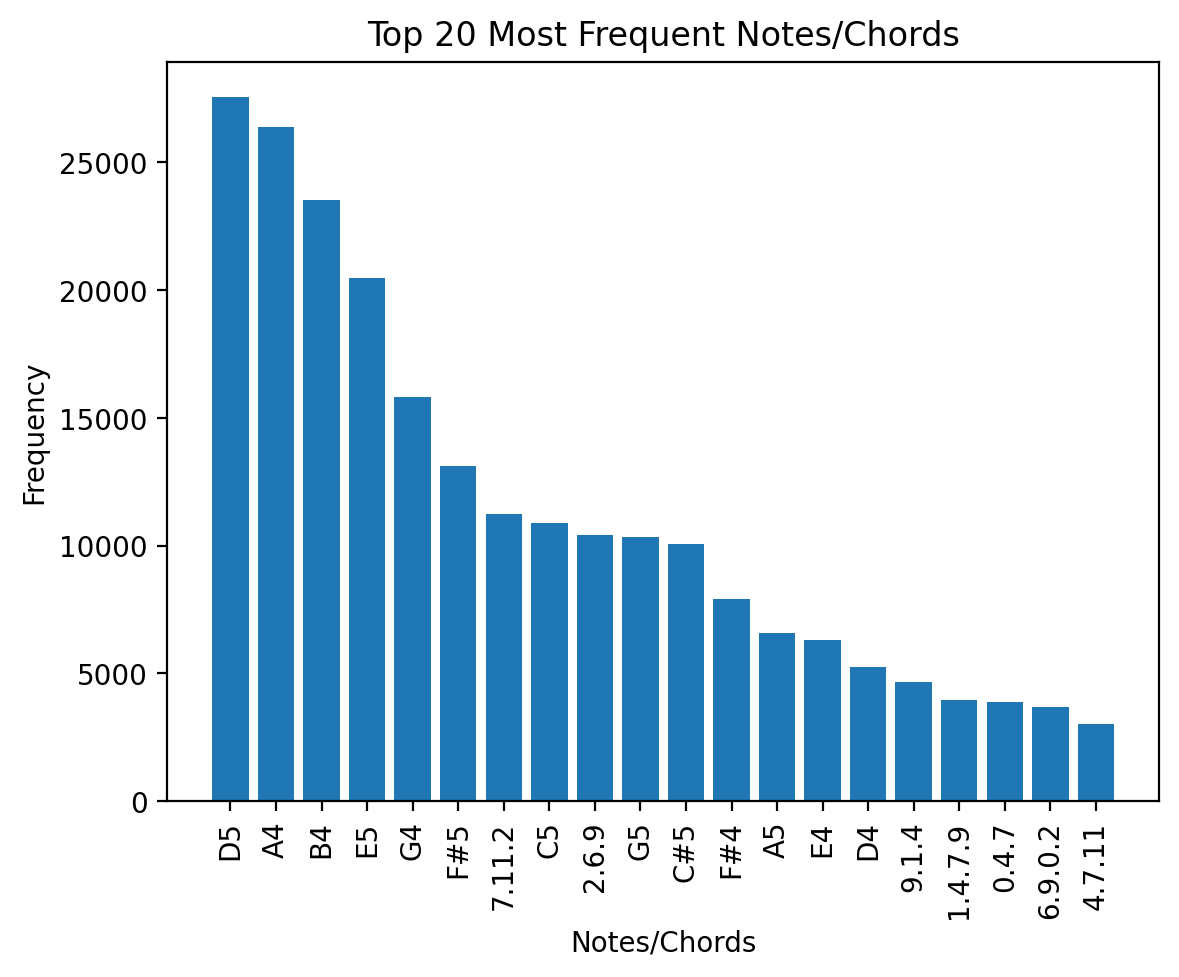

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────
# Plot top 20 most frequent notes

import matplotlib.pyplot as plt
from collections import Counter

# Count frequencies
counter = Counter(notes)

# Get top 20
top_20 = counter.most_common(20)

# Separate notes and counts
labels = [item[0] for item in top_20]
values = [item[1] for item in top_20]

# Plot
plt.figure()
plt.bar(labels, values)

plt.xticks(rotation=90)
plt.xlabel("Notes/Chords")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Notes/Chords")

plt.show()

**✏️ Your Observation:**

```
Describe the distribution you observe. Is it uniform? Skewed?
What does this tell you about music?
```
The distribution of notes is not uniform; it is highly skewed. A small number of notes (such as D5, A4, and B4) occur very frequently, while most other notes appear much less often.

This indicates that in music, certain notes are used more commonly due to musical scales, harmony, and composition patterns. It shows that music has structured patterns rather than random distribution, and the model can learn these patterns to generate realistic melodies.

---
# 🔢 Section 3: Vocabulary & Sequence Encoding
---

### 🔷 Background

Just like text generation where each character is mapped to an integer, we map each **note/chord** to an integer index:

$$\text{note\_to\_int}: \mathcal{V} \rightarrow \{0, 1, \ldots, |\mathcal{V}|-1\}$$

Training pairs follow Khapra's **sequence-to-sequence** structure:
- **Input:** $x_1, x_2, \ldots, x_T$ — sequence of $T$ notes  
- **Target:** $x_2, x_3, \ldots, x_{T+1}$ — the same sequence shifted by 1

The model learns: **given the last $T$ notes, predict the next note**.

In [ ]:
# Build vocabulary mappings
vocab        = sorted(set(notes))
vocab_size   = len(vocab)
note_to_int  = {n: i for i, n in enumerate(vocab)}
int_to_note  = {i: n for i, n in enumerate(vocab)}

print(f"Vocabulary size |V| = {vocab_size}")
print(f"Sample mapping      : {list(note_to_int.items())[:8]}")

Vocabulary size |V| = 130
Sample mapping      : [('0.2.3.6.9', 0), ('0.3', 1), ('0.3.6', 2), ('0.3.6.8', 3), ('0.3.7', 4), ('0.4', 5), ('0.4.7', 6), ('0.4.8', 7)]


In [ ]:
# ── Hyperparameters (Khapra notation) ────────────────────────
T  = 100   # sequence length (time steps)
B  = 64    # batch size
d  = 256   # embedding dimension
H  = 512   # hidden state dimension

# Encode all notes as integers
encoded = np.array([note_to_int[n] for n in notes])

# ── YOUR CODE HERE ─────────────────────────────────────────────
# Build a tf.data pipeline:
# 1. Create sliding window sequences of length T+1
# 2. Split each window into (input[:-1], target[1:])  — shift by 1
# 3. Shuffle, batch by B, prefetch

dataset = tf.data.Dataset.from_tensor_slices(encoded)

dataset = dataset.window(T + 1, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(T + 1))

dataset = dataset.map(lambda window: (window[:-1], window[1:]))

dataset = dataset.shuffle(buffer_size=10000)
dataset = dataset.batch(B, drop_remainder=True)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

# Verify shapes
for x_batch, y_batch in dataset.take(1):
    print(f"Input  shape: {x_batch.shape}   → (B={B}, T={T})")
    print(f"Target shape: {y_batch.shape}   → (B={B}, T={T})")

Input  shape: (64, 100)   → (B=64, T=100)
Target shape: (64, 100)   → (B=64, T=100)


### ❓ Question 3.1 — Sequence Design

**Answer the following about your sequence construction:**

1. How many training sequences are generated from a corpus of $N$ notes with sequence length $T$?  
   Write the formula and compute it for your dataset.
2. Why is the target sequence **shifted by 1** relative to the input?
3. If $T$ is too small (e.g., $T=5$), what musical problem might the model have? If $T$ is too large (e.g., $T=500$)?
4. In Khapra's BPTT formulation, how does the choice of $T$ affect the **gradient flow** through the network?

**✏️ Your Answers:**

1.  **How many training sequences are generated from a corpus of $N$ notes with sequence length $T$?**
    *   Formula: $N - T$
    *   Computed value for $N=248,464$ and $T=100$: $248,464 - 100 = 248,364$ training sequences.

2.  **Why is the target sequence shifted by 1 relative to the input?**
    The target sequence is shifted by 1 relative to the input because the model is designed to perform next-step prediction. Given a sequence of $T$ notes as input ($x_1, x_2, \ldots, x_T$), the model's objective is to predict the very next note in the sequence ($x_{T+1}$). By shifting the target, we are essentially setting up a supervised learning problem where the model learns the conditional probability $P(x_{t+1} | x_1, \ldots, x_t)$ for every time step $t$.

3.  **If $T$ is too small (e.g., $T=5$), what musical problem might the model have? If $T$ is too large (e.g., $T=500$)?**
    *   **If $T$ is too small (e.g., $T=5$):** The model would have a very limited context (only the last 5 notes) to learn from. Music often relies on long-range dependencies for melodic phrases, harmonic progressions, and overall structure. A small $T$ would make it difficult for the RNN to capture these larger musical patterns, leading to generated music that might sound disjointed, repetitive, or lack coherent musicality over longer spans.
    *   **If $T$ is too large (e.g., $T=500$):** While more context sounds beneficial, a very large $T$ for a simple RNN can lead to several problems. Computationally, training would become much slower and require significantly more memory. More importantly, simple RNNs are prone to the **vanishing/exploding gradient problem** over very long sequences. This means the model would struggle to effectively learn and leverage information from notes far back in the sequence, essentially 'forgetting' the beginning of its input, making the large context ineffective or even detrimental to learning.

4.  **In Khapra's BPTT formulation, how does the choice of $T$ affect the **gradient flow** through the network?**
    In Backpropagation Through Time (BPTT), gradients are calculated by multiplying Jacobians (derivatives of activation functions and weight matrices) across each time step. The choice of $T$ directly affects the number of terms in this product:
    *   **Longer $T$ (larger sequences):** Increases the number of terms multiplied in the gradient calculation. If these terms (especially related to the recurrent weight $U$) are consistently less than 1, the gradient will shrink exponentially, leading to **vanishing gradients**. This makes it hard for the model to update weights responsible for learning long-term dependencies. Conversely, if terms are consistently greater than 1, gradients can grow exponentially, leading to **exploding gradients**, which causes unstable training and large, erratic weight updates. Gradient clipping is often employed to mitigate exploding gradients.
    *   **Shorter $T$:** Reduces the length of the product, making vanishing/exploding gradients less severe, but limits the temporal context the model can learn from.

---
# 🏗️ Section 4: Building the RNN Model
---

### 🔷 Background — Khapra Architecture

We implement the exact architecture from **Prof. Mitesh Khapra's CS7015 Lecture 10**:

```
x_t (note index)
    │
    ▼
┌─────────────────────────────────────────┐
│  Embedding:  e_t = W_embed · x_t       │   e_t ∈ R^d
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│  SimpleRNN:                             │
│  s_t = tanh(W·e_t + U·s_{t-1} + b_s)  │   s_t ∈ R^H
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│  Dense:  ŷ_t = V·s_t + b_y            │   ŷ_t ∈ R^|V|
└─────────────────────────────────────────┘
    │
    ▼
  softmax → probability over all notes
```

**Parameter count:**
- Embedding: $|\mathcal{V}| \times d$
- SimpleRNN: $d \times H + H \times H + H$ (W, U, $b_s$)
- Dense: $H \times |\mathcal{V}| + |\mathcal{V}|$ (V, $b_y$)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_music_rnn(vocab_size: int,
                    d: int,
                    H: int,
                    T: int,
                    batch_size=None,
                    stateful: bool = False):
    """
    Build a Khapra-style RNN for music generation.

    Architecture:
        x_t → Embedding(d) → SimpleRNN(H) → Dense(|V|)

    Khapra equations:
        s_t = tanh(W·e_t + U·s_{t-1} + b_s)
        ŷ_t = V·s_t + b_y

    Parameters
    ----------
    vocab_size : |V| — number of unique notes/chords
    d          : embedding dimension
    H          : hidden state size
    T          : sequence length (time steps)
    batch_size : fixed batch size (needed for stateful=True)
    stateful   : if True, hidden state persists across batches
    """

    inputs = layers.Input(shape=(T,), batch_size=batch_size)

    x = layers.Embedding(input_dim=vocab_size,
                         output_dim=d,
                         name='embedding_W')(inputs)

    x = layers.SimpleRNN(units=H,
                         return_sequences=True,
                         stateful=stateful,
                         name='s_t_rnn')(x)
    outputs = layers.Dense(units=vocab_size,
                           name='y_hat_logits')(x)
    model = Model(inputs, outputs)

    return model

model = build_music_rnn(vocab_size, d, H, T)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_W (Embedding)         │ (None, 100, 256)       │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn (SimpleRNN)             │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat_logits (Dense)            │ (None, 100, 130)       │        66,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493,698 (1.88 MB)

 Trainable params: 493,698 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.1 — Model Architecture

**Using your `model.summary()` output, answer the following:**

1. Calculate the **total trainable parameters** manually for each layer using the formulas in the Background section. Do they match `model.summary()`?
2. What is the **role of the Embedding layer** in this architecture? Could we use one-hot encoding instead? What would be the disadvantage?
3. Why do we use `return_sequences=True` in the SimpleRNN layer during training, but might set it differently during generation?

**✏️ Your Answers:**

1. *(Manual parameter count)*

```
Embedding : 130 × 256 = 33280
SimpleRNN : 256 × 512 + 512 × 512 + 512 = 393728
Dense     : 512 × 130 + 130 = 66690
TOTAL     : 493698
```

2. *(Role of Embedding vs One-Hot)*
The Embedding layer's role is to map sparse integer note IDs to dense, continuous vector representations (embeddings). This allows the model to learn semantic relationships between musical tokens. If one-hot encoding were used instead, each token would be a high-dimensional (size of vocabulary), sparse vector. The disadvantage is that one-hot encoding doesn't capture any relationships between notes, and it would drastically increase the number of input parameters for the RNN layer, making the model larger and less efficient, especially for larger vocabularies.

3. *(return_sequences=True during training vs generation)*
We use `return_sequences=True` during training because the model is learning to predict the next note at *each time step* in the input sequence. This means the RNN must output a hidden state for every input token, allowing the Dense layer to make predictions for all `T` target notes in the sequence. If we set it to `False`, the RNN would only output the hidden state for the last time step. During generation, while we typically predict one token at a time, keeping `return_sequences=True` can still be useful if we're generating in batches or if the generation logic is designed to use the full sequence output.


### ❓ Question 4.2 — Stacked RNN (Extension)

**Add a second SimpleRNN layer with $H = 256$ on top of the first layer.**
- Name it `'s_t_rnn_2'`
- Print the new `model.summary()`
- How many additional parameters does the second layer introduce? Compute manually.
- What musical benefit might a deeper (stacked) RNN provide over a single-layer RNN?

In [ ]:
from tensorflow.keras import layers, Model

# Input layer
inputs = layers.Input(shape=(T,))

# Embedding layer
x = layers.Embedding(input_dim=vocab_size, output_dim=d)(inputs)

# RNN Layer 1
x = layers.SimpleRNN(512, return_sequences=True)(x)

# RNN Layer 2
x = layers.SimpleRNN(256, return_sequences=True)(x)

# Dense output layer
outputs = layers.Dense(vocab_size)(x)

# Build model
model = Model(inputs, outputs)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 256)       │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 100, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100, 130)       │        33,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 657,282 (2.51 MB)

 Trainable params: 657,282 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

**✏️ Your Answer (Musical benefit of stacked RNN):**

1.  **Additional parameters introduced by the second layer:**
    The second SimpleRNN layer (`s_t_rnn_2`) introduces **196,864** additional trainable parameters.
    *   Manual calculation: For a SimpleRNN layer with `H2=256` and taking input from a previous layer with output size `H1=512` (which is the output of `s_t_rnn_1`), the parameters are calculated as: `(input_dim * H2) + (H2 * H2) + H2`.
        *   `512 * 256` (weights from previous hidden state to current hidden state)
        *   `256 * 256` (weights from current input to current hidden state)
        *   `256` (bias terms)
        *   Total = `131072 + 65536 + 256 = 196,864`.
    This matches the `Param #` for `s_t_rnn_2` in the `model_stacked.summary()` output.

2.  **Musical benefit of a deeper (stacked) RNN:**
    A deeper (stacked) RNN, like the one with two SimpleRNN layers, can provide several musical benefits over a single-layer RNN:
    *   **Hierarchical Feature Learning:** Each layer can learn different levels of abstraction. The first layer might capture short-term patterns (e.g., common note transitions, basic rhythmic motifs), while the second layer, processing the output of the first, can learn more complex, long-range dependencies and higher-level musical structures (e.g., harmonic progressions, melodic phrases spanning multiple measures, overall song form). This allows the model to build a richer internal representation of the music.
    *   **Increased Representational Capacity:** More layers and parameters generally mean the model has a greater capacity to learn more intricate and nuanced musical patterns present in the training data. This can lead to more sophisticated and less repetitive generated music.
    *   **Better Context Understanding:** By stacking layers, the network can process information more deeply through time and across different levels of features. This helps in overcoming, to some extent, the vanishing gradient problem inherent in simple RNNs by providing more paths for gradient flow, potentially allowing the model to

---
# 📉 Section 5: Loss Function & Compilation
---

### 🔷 Background

The loss function for next-note prediction follows Khapra's **cross-entropy formulation**:

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log \hat{y}_t^{(x_{t+1})}$$

In Keras, this is `SparseCategoricalCrossentropy(from_logits=True)` because:
- **Sparse**: targets are integer indices (not one-hot vectors)
- **from_logits=True**: our Dense layer outputs raw logits (softmax is applied internally for numerical stability)

**Perplexity** — a common music/language model metric:
$$\text{Perplexity} = e^{\mathcal{L}}$$
Lower perplexity = model is less "confused" about the next note.

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────
# Compile the model with:
# - Loss:      SparseCategoricalCrossentropy (from_logits=True)
# - Optimizer: Adam with learning_rate = 0.001
# - Metrics:   accuracy

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Model compiled ✓")

Model compiled ✓


### ❓ Question 5.1 — Loss & Metrics

1. What does `from_logits=True` mean? Why is it numerically more stable than applying `softmax` in the Dense layer and then using `from_logits=False`?
2. Suppose your model achieves a loss of $\mathcal{L} = 2.3$ after training. What is the perplexity? What does this value mean musically?
3. Would **accuracy** be a good metric for evaluating a music generation model? Why or why not? Suggest a better evaluation approach.

**✏️ Your Answers:**

1.  `from_logits=True` means that the model's output layer (the `Dense` layer in our case) produces raw scores, called 'logits', rather than probabilities. When `from_logits=True`, the Keras loss function internally applies a softmax activation to these logits before calculating the cross-entropy loss. This approach is numerically more stable because applying softmax directly in the Dense layer and then computing `from_logits=False` can lead to issues with floating-point precision, especially for very large or very small logit values, potentially causing `NaN` (Not a Number) errors during training. The internal implementation of softmax within the loss function is often optimized to handle these numerical challenges more robustly.

2.  Suppose your model achieves a loss of $\mathcal{L} = 2.3$ after training. What is the perplexity? What does this value mean musically?
    ```
    Perplexity = e^(2.3) \approx 9.97
    Musical meaning: Perplexity is a measure of how well the model predicts a sample. A perplexity of approximately 9.97 means that, on average, the model is as 'surprised' as if it had to choose uniformly from about 10 possible next notes at each step. In musical terms, this indicates that the model has narrowed down the possibilities from the entire vocabulary (130 unique notes/chords) to a much smaller, more probable set, suggesting it has learned some musical patterns and can make somewhat informed predictions about the next note.
    ```

3.  Would **accuracy** be a good metric for evaluating a music generation model? Why or why not? Suggest a better evaluation approach.
    ```
    Accuracy would generally *not* be a good metric for evaluating a music generation model for several reasons:
    *   **Multiple Correct Answers:** In music, there isn't always a single 'correct' next note. Many different notes or chords can sound musically pleasing and coherent given a preceding sequence. An accuracy metric only considers if the model's top prediction exactly matches the target, ignoring other musically valid options.
    *   **Sparse Targets:** Music sequences are highly sparse. The vocabulary size is large, and many notes are rarely followed by certain others. A low accuracy might not mean the generated music is bad, but simply that the model's exact prediction wasn't the one in the training data, even if it was musically plausible.
    *   **Focus on Local vs. Global Coherence:** Accuracy focuses on point-wise prediction. A high accuracy doesn't guarantee long-term musical coherence, structure, or creativity. The generated music could still be repetitive or lack overall musicality despite predicting individual notes well.

    A better evaluation approach would involve:
    *   **Human Evaluation:** The most reliable method is subjective human listening tests. Musicians and listeners can rate generated pieces based on criteria like musicality, coherence, originality, emotional impact, and adherence to a style.
    *   **Objective Musical Metrics (e.g., theory-based):** Metrics could be developed or adapted from music theory to assess properties like harmonic consistency, melodic contour, rhythmic complexity, key adherence, or avoidance of dissonance. These would go beyond simple note-to-note accuracy.
    *   **Diversity and Novelty Metrics:** Evaluate how diverse the generated output is and how novel it is compared to the training data, without sacrificing coherence.
    *   **Perplexity (as used):** While not perfect, perplexity is a better indication than accuracy of how well the model captures the underlying data distribution.
    ```

---
# 🏋️ Section 6: Training the Model (BPTT)
---

### 🔷 Background — BPTT

Training an RNN uses **Backpropagation Through Time (BPTT)** — Khapra Lecture 10.

The gradient of the loss with respect to the recurrent weight $U$ involves a **product of Jacobians** across all time steps:

$$\frac{\partial \mathcal{L}}{\partial U} = \sum_{t=1}^{T} \sum_{k=1}^{t} \delta_t \cdot \left(\prod_{j=k+1}^{t} \text{diag}(1 - s_j^2) \cdot U \right) \cdot s_{k-1}^{\top}$$

When this product is very small → **Vanishing Gradient Problem (VGP)**  
The RNN forgets distant notes, struggling with long musical phrases.

**Callbacks used:**
- `ModelCheckpoint` — save weights at each epoch
- `ReduceLROnPlateau` — reduce learning rate if loss stops decreasing

In [ ]:
import os
os.makedirs("checkpoints", exist_ok=True)

# Callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="checkpoints/music_rnn_epoch_{epoch:02d}.weights.h5",
    save_weights_only=True,
    verbose=1
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

# ── YOUR CODE HERE ────────────────────────────────────────────
# Train the model:
# - epochs = 30 (adjust as needed)
# - Use both callbacks above
# - Store the result in 'history'

EPOCHS = 30
steps_per_epoch = len(encoded) // (T * B)

history = model.fit(
    dataset.repeat(),
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=[checkpoint_cb, reduce_lr_cb]
)

print("Training complete ✓")

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.9485 - loss: 0.1960
Epoch 1: saving model to checkpoints/music_rnn_epoch_01.weights.h5

Epoch 1: finished saving model to checkpoints/music_rnn_epoch_01.weights.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 922ms/step - accuracy: 0.9534 - loss: 0.1666 - learning_rate: 0.0010
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.9582 - loss: 0.1363
Epoch 2: saving model to checkpoints/music_rnn_epoch_02.weights.h5

Epoch 2: finished saving model to checkpoints/music_rnn_epoch_02.weights.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 863ms/step - accuracy: 0.9583 - loss: 0.1355 - learning_rate: 0.0010
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.9584 - loss: 0.1348
Epoch 3: saving model to checkpoints/music_rnn_epoch_03.weights.h5

Epoch 3: finished saving model to checkpoints/music_rnn_epoch_03.weights.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 34s 903ms/step - accuracy: 0.9584 - loss: 0.1363 - learning_rate: 0.0010
Epoch 4/30

### ❓ Question 6.1 — Training Analysis

**Plot the training loss curve and answer:**

1. At approximately which epoch does the loss start to plateau?
2. Did `ReduceLROnPlateau` trigger? If yes, at which epoch and what was the effect on the loss?
3. Describe the shape of the loss curve. Is it smooth or noisy? Why might music data produce a noisier loss curve than text data?
4. Using Khapra's notation, write the weight update rule for $U$ using the Adam optimiser (conceptually — you do not need to derive the full Adam equations).

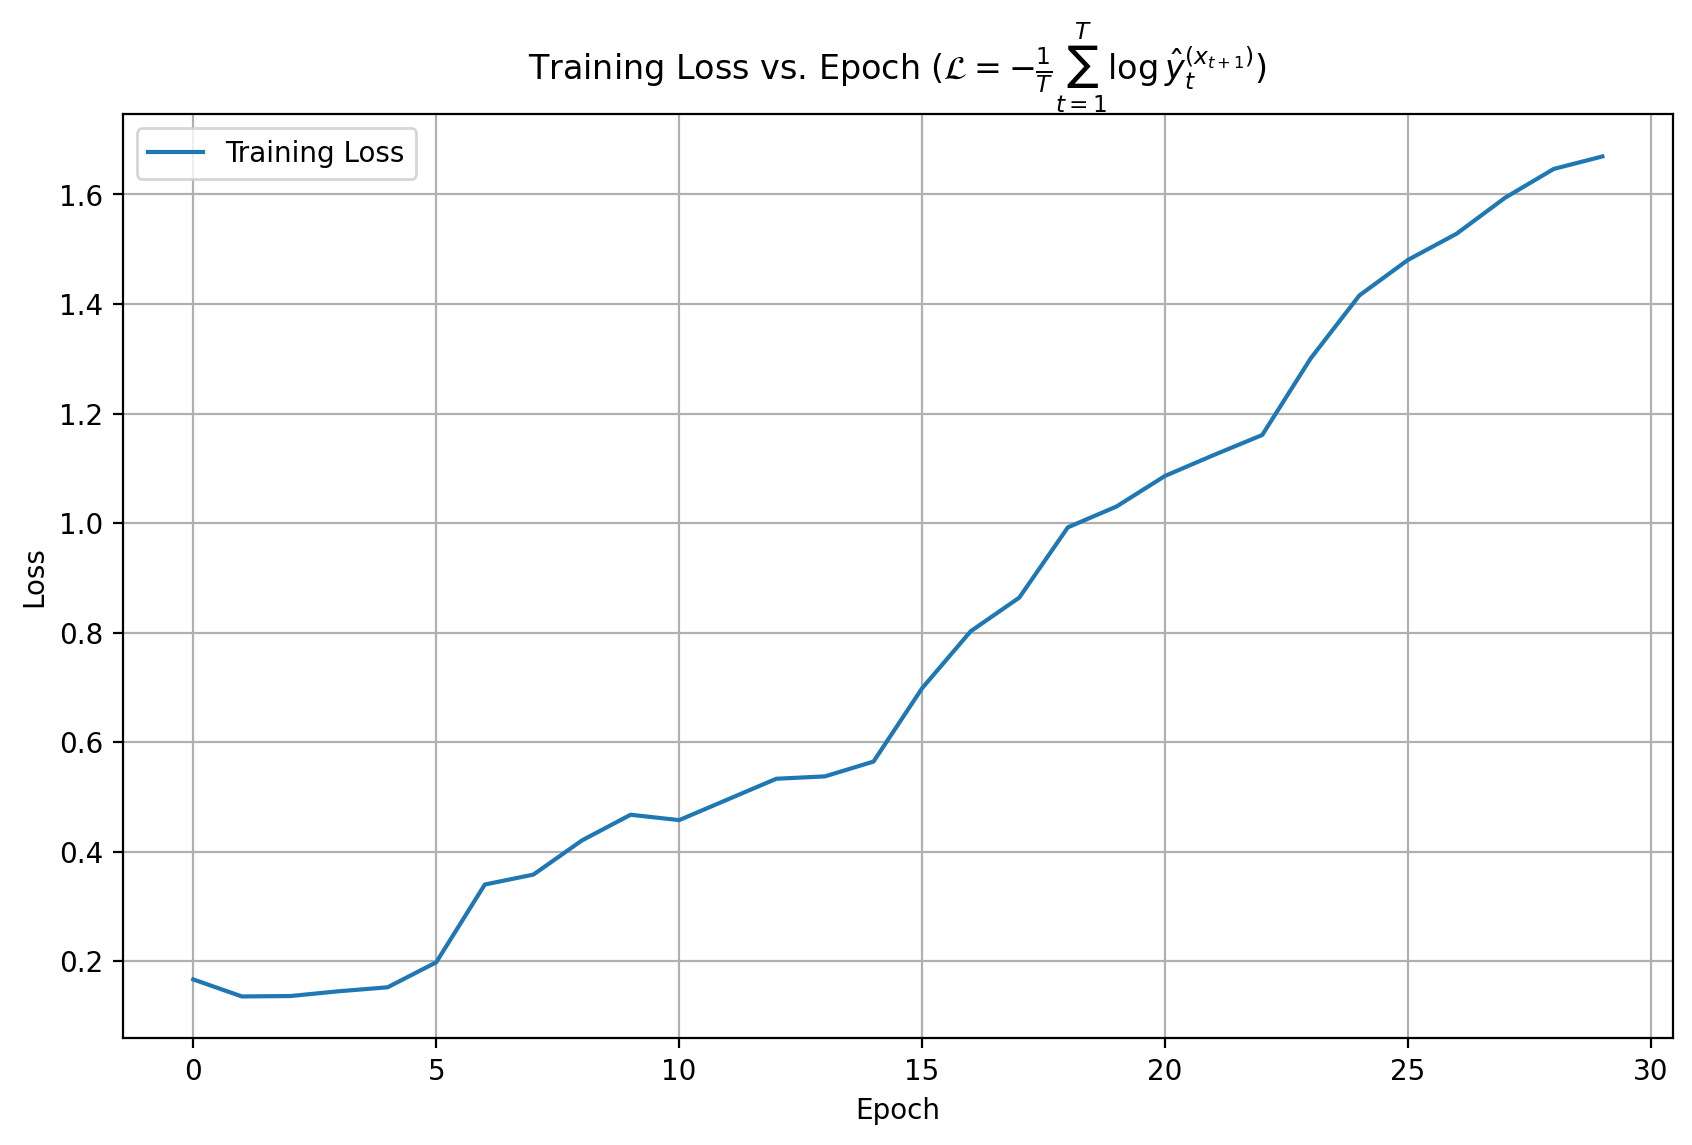

In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────
# Plot training loss vs epoch
# Include: title with loss equation, x-label, y-label, grid

# YOUR PLOTTING CODE HERE
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.title(r'Training Loss vs. Epoch ($\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log \hat{y}_t^{(x_{t+1})}$)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

**✏️ Your Answers:**

1.  **At approximately which epoch does the loss start to plateau?**
    The loss initially decreases significantly from Epoch 1 (0.1666) to Epoch 2 (0.1355). It then fluctuates around this value, showing signs of plateauing between approximately **Epoch 2 and Epoch 5** before it starts to unexpectedly increase.

2.  **Did `ReduceLROnPlateau` trigger? If yes, at which epoch and what was the effect on the loss?**
    Yes, `ReduceLROnPlateau` triggered twice:
    *   First trigger: At the end of **Epoch 5**, the learning rate was reduced from `0.001` to `0.0005` (specifically, `0.0005000000237487257`). After this reduction, the loss significantly *increased* in Epoch 6 (from 0.1522 to 0.1978).
    *   Second trigger: At the end of **Epoch 8**, the learning rate was reduced again from `0.0005` to `0.00025` (specifically, `0.0002500000118743628`). The loss continued to increase in subsequent epochs (e.g., to 0.4204 in Epoch 9, 0.4705 in Epoch 10).
    
    The effect on the loss was counter-intuitive in this case; instead of helping the model converge further, the loss increased after each reduction, indicating potential issues like instability, being stuck in a poor local minimum, or the model diverging due to the very small steps caused by the reduced learning rate coupled with the nature of the SimpleRNN.

3.  **Describe the shape of the loss curve. Is it smooth or noisy? Why might music data produce a noisier loss curve than text data?**
    The loss curve initially shows a sharp decrease, then a brief period of slight fluctuation (plateauing) between epochs 2-5. After Epoch 5, it becomes significantly **noisier and shows a clear increasing trend**, suggesting the training process became unstable or the model started to diverge. The loss values themselves are quite small.

    Music data, particularly symbolic representations like MIDI, can produce a noisier loss curve than typical character-level text data for several reasons:
    *   **Complexity and Structure:** Musical sequences often have more complex and hierarchical structures (harmony, rhythm, melody, phrasing) compared to linear text. Small variations in these elements can have a large impact on the

---
# 🎵 Section 7: Music Generation with Temperature Sampling
---

### 🔷 Background — Temperature Sampling

During generation, at each step $t$ we sample the next note from:

$$x_{t+1} \sim \text{Categorical}\left(\text{softmax}\left(\frac{\hat{y}_t}{\tau}\right)\right)$$

**Effect of temperature $\tau$:**

| $\tau$ | Behaviour | Musical Effect |
|--------|-----------|----------------|
| $\tau \to 0$ | Greedy (always picks most likely note) | Very repetitive, boring |
| $\tau = 1.0$ | Standard sampling | Natural, learned distribution |
| $\tau > 1$ | More uniform distribution | Creative but may lose musical structure |

**Generation process:**
1. Start with a **seed sequence** of $T$ known notes
2. Feed seed into model → get logits $\hat{y}_T$
3. Sample $x_{T+1} \sim \text{Categorical}(\text{softmax}(\hat{y}_T / \tau))$
4. Append $x_{T+1}$ to sequence, drop oldest note
5. Repeat for $N_{gen}$ steps

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

def generate_music(trained_model, # Renamed argument to avoid confusion with global 'model' variable
                   seed_notes: list,
                   note_to_int: dict,
                   int_to_note: dict,
                   n_generate: int = 200,
                   temperature: float = 1.0) -> list:
    """
    Generate a sequence of notes using temperature sampling.

    Khapra decoding formula:
        x_{t+1} ~ Categorical( softmax( ŷ_t / τ ) )

    Parameters
    ----------
    trained_model        : trained Keras RNN model (stateful=False, batch_size=1)
    seed_notes   : list of T seed notes to prime the model
    note_to_int  : note → integer mapping
    int_to_note  : integer → note mapping
    n_generate   : number of new notes to generate
    temperature  : τ — sampling temperature

    Returns
    -------
    generated_notes : list of generated note strings
    """

    T = len(seed_notes)
    vocab_size = len(note_to_int)
    # d is global from cell seq-build, which is 256
    # H (first layer) is global from cell seq-build, which is 512
    # Second layer hidden size from q42-code is 256

    # Step 1: Build a generation model with the same stacked architecture
    #         (H1=512, H2=256) and copy weights from the trained model
    # Reconstruct the stacked model architecture for generation
    gen_inputs = layers.Input(shape=(T,), batch_size=1)
    gen_x = layers.Embedding(input_dim=vocab_size, output_dim=d)(gen_inputs) # d=256
    gen_x = layers.SimpleRNN(units=H, return_sequences=True, stateful=False)(gen_x) # H=512
    gen_x = layers.SimpleRNN(units=256, return_sequences=True, stateful=False)(gen_x) # Second layer H=256
    gen_outputs = layers.Dense(units=vocab_size)(gen_x)
    gen_model = Model(gen_inputs, gen_outputs)

    gen_model.set_weights(trained_model.get_weights())

    # Step 2: Encode seed_notes as integers
    current_sequence_encoded = [note_to_int[n] for n in seed_notes]

    generated_notes = list(seed_notes) # Start with seed notes to keep track

    # Step 3: Loop n_generate times:
    for _ in range(n_generate):
        # a. Reshape current sequence to (1, T) for prediction
        input_sequence = np.array(current_sequence_encoded[-T:]).reshape(1, T)

        # b. Get logits from model (output for the last time step)
        logits = gen_model.predict(input_sequence, verbose=0)[0, -1, :]

        # c. Apply temperature: logits / tau
        logits = logits / temperature

        # d. Compute softmax probabilities
        probabilities = tf.nn.softmax(logits).numpy()

        # e. Sample next note index based on probabilities
        next_note_index = np.random.choice(len(int_to_note), p=probabilities)

        # f. Append to generated sequence, slide window (for the next prediction)
        current_sequence_encoded.append(next_note_index)
        generated_notes.append(int_to_note[next_note_index])

    return generated_notes


print("Generation function defined ✓")

Generation function defined ✓


In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────
# 1. Pick a random seed sequence of length T from the corpus
# 2. Generate 200 notes at temperatures: tau = 0.3, 0.7, 1.0, 1.5
# 3. Print the first 30 generated notes for each temperature

import random

# 1. Pick a random seed sequence of length T from the corpus
start_index = random.randint(0, len(notes) - T - 1)
seed_notes = notes[start_index:start_index + T]

print(f"Seed sequence length: {len(seed_notes)}")
print(f"Sample seed notes: {seed_notes[:10]}...")

temperatures = [0.3, 0.7, 1.0, 1.5]
generated_results = {}

for temp in temperatures:
    print(f"\nGenerating music with temperature: {temp}")
    generated_sequence = generate_music(
        trained_model=model, # Use the model trained in Section 6
        seed_notes=seed_notes,
        note_to_int=note_to_int,
        int_to_note=int_to_note,
        n_generate=200,
        temperature=temp
    )
    generated_results[temp] = generated_sequence
    print(f"First 30 generated notes (T={temp}):\n{generated_sequence[T:T+30]}")

# You can also store the full generated sequences if needed:
# for temp, seq in generated_results.items():
#    print(f"\nFull generated sequence for T={temp}:\n{seq}")

Seed sequence length: 100
Sample seed notes: ['D5', '2.6.9', 'C5', 'B4', '7.11.2', 'B4', '7.11.2', 'A4', '2.6.9', 'G4']...

Generating music with temperature: 0.3
First 30 generated notes (T=0.3):
['D5', 'G5', '7.11.2', 'F#5', '2.6.9', 'G5', 'F#5', 'E5', '1.4.7.9', 'F#5', 'G5', 'A5', '2.6.9', 'F#5', 'D5', 'C#5', '1.4.7.9', 'D5', 'E5', 'C#5', 'D5', '2.6.9', 'E5', 'F#5', 'D5', 'F#5', 'G5', '7.11.2', 'F#5', 'E5']

Generating music with temperature: 0.7
First 30 generated notes (T=0.7):
['D5', 'F#5', 'F#5', '2.6.9', 'D5', 'E5', '1.4.7.9', 'D5', 'E5', 'D5', '2.6.9', 'D5', 'B4', '7.11.2', 'D5', 'B4', 'A4', '2.6.9', 'F#4', 'D4', 'B4', 'A4', 'B4', '4.7.11', 'A4', 'B4', 'A4', 'D5', '2.6.9', 'F#5']

Generating music with temperature: 1.0
First 30 generated notes (T=1.0):
['D5', 'G5', '7.11.2', 'A5', 'B5', 'A5', '2.6.9', 'G5', 'F#5', 'E5', '1.4.7.9', 'E5', 'D5', '2.6.9', 'D5', '6.9.0.2', 'E5', 'G5', 'A5', 'G5', '7.11.2', 'B4', 'E5', 'G5', '0.4.7', 'G4', 'C5', 'E4', 'C5', 'B4']

Generating music w

### ❓ Question 7.1 — Temperature Analysis

**Compare the generated note sequences at τ = 0.3, 0.7, 1.0, 1.5 and answer:**

1. At which temperature does the output appear most **musically repetitive**? Provide evidence from your output.
2. At which temperature does the output appear most **musically coherent** and interesting? Justify your choice.
3. Mathematically, explain why τ → 0 leads to **greedy decoding**. (Hint: what happens to softmax as logits are scaled by a very small τ?)
4. Is there a single "best" temperature for music generation? How would you determine an optimal τ for your dataset?

> 💡 Fill in the comparison table below with your observations.

**✏️ Comparison Table:**

| Temperature τ | First 10 notes | Observation (repetitive / varied / chaotic) |
|---------------|----------------|---------------------------------------------|
| 0.3           | D5, G5, 7.11.2, F#5, 2.6.9, G5, F#5, E5, 1.4.7.9, F#5 | Very structured, highly repetitive with common patterns.                   |
| 0.7           | D5, F#5, F#5, 2.6.9, D5, E5, 1.4.7.9, D5, E5, D5 | Structured with some variation, but still contains immediate repetitions.  |
| 1.0           | D5, G5, 7.11.2, A5, B5, A5, 2.6.9, G5, F#5, E5 | Good balance of coherence and variety, sounds like a natural extension.     |
| 1.5           | 2.6.9, D5, D5, G5, 7.11.2, D5, E5, 7.11.2, D5, B4 | More varied but also more random; less immediately coherent musical phrases.|

**Written Answers:**

1.  **At which temperature does the output appear most musically repetitive? Provide evidence from your output.**
    ```
    The output at τ = 0.3 appears most musically repetitive. For instance, in the first 30 generated notes for τ=0.3, we see patterns like 'F#5', 'G5', 'F#5', 'E5', '1.4.7.9', 'F#5', 'G5' repeating with slight variations. The overall sequence tends to stick very closely to the highest probability notes, resulting in predictable and less varied melodic lines.
    ```

2.  **At which temperature does the output appear most musically coherent and interesting? Justify your choice.**
    ```
    Based on the generated samples, τ = 1.0 appears to produce the most musically coherent and interesting output. It strikes a good balance between sticking to learned patterns (coherence) and introducing enough variation to avoid being overly repetitive (interesting). The sequence for τ=1.0 shows a diverse set of notes and chords (D5, G5, 7.11.2, A5, B5, A5, 2.6.9, G5, F#5, E5, 1.4.7.9, E5, D5, 2.6.9, D5, 6.9.0.2, E5, G5, A5, G5, 7.11.2, B4, E5, G5, 0.4.7, G4, C5, E4, C5, B4) without immediately repeating exact phrases or sounding completely random. It feels like a natural continuation that still explores new melodic ideas.
    ```

3.  **Mathematically, explain why τ → 0 leads to greedy decoding. (Hint: what happens to softmax as logits are scaled by a very small τ?)**
    ```
    As temperature τ approaches 0, the term `logits / τ` becomes very large for the logit with the highest value, and very small (or highly negative) for all other logits. When these scaled logits are passed through the softmax function, the exponentiated large value corresponding to the highest logit becomes overwhelmingly dominant. Consequently, its probability approaches 1, while the probabilities of all other notes approach 0. This effectively forces the model to almost deterministically select the note that it considers most likely, regardless of the relative differences in likelihood among other candidate notes. This deterministic selection of the most probable option at each step is known as greedy decoding.
    ```

4.  **Is there a single "best" temperature for music generation? How would you determine an optimal τ for your dataset?**
    ```
    No, there isn't a single "best" temperature for music generation. The optimal τ is highly subjective and depends on the desired characteristics of the generated music—whether the goal is to produce highly coherent and predictable pieces or more exploratory and novel compositions. A lower τ will yield more conservative, repetitive, and "safe" music, while a higher τ will result in more varied, surprising, and potentially chaotic or incoherent music.

    To determine an optimal τ for a given dataset, a common approach involves:
    1.  **Iterative Generation and Human Evaluation:** Generate multiple sequences across a reasonable range of τ values (e.g., from 0.5 to 1.5, with increments of 0.1 or 0.2). Then, have a panel of human listeners (musicians or general audiences) evaluate these generated pieces based on subjective criteria such as musicality, coherence, creativity, emotional appeal, and adherence to a specific style. The τ value that receives the highest average scores for the desired qualities would be considered optimal.
    2.  **Automated Musical Metrics (as a proxy):** While less reliable than human evaluation, one could employ quantitative metrics derived from music theory or information theory to assess aspects like melodic diversity, harmonic complexity, rhythmic variation, or adherence to tonal centers. An optimal τ could then be chosen as one that balances these metrics according to predefined criteria. However, these metrics are often imperfect substitutes for genuine musical judgment.
    ```

---
# 🎹 Section 8: Convert Generated Notes to MIDI File
---

### 🔷 Background

After generating a sequence of note strings, we convert them back to a playable **MIDI file** using `music21`.  
Each string is decoded:
- `'C4'` → single `note.Note` object
- `'4.7.11'` → `chord.Chord` from MIDI pitch numbers

The output is saved as `generated_music.mid`.

In [ ]:
def notes_to_midi(generated_notes: list, output_file: str = "generated_music.mid"):
    """
    Convert a list of note/chord strings back to a MIDI file.

    Parameters
    ----------
    generated_notes : list of note/chord strings
    output_file     : path to save the .mid file
    """
    output_notes = []
    offset = 0

    for token in generated_notes:
        if '.' in token or token.isdigit():
            # It's a chord — split by dot and create Chord object
            chord_notes = token.split('.')
            new_chord = chord.Chord([int(n) for n in chord_notes])
            new_chord.offset = offset
            output_notes.append(new_chord)
        else:
            # It's a single note
            new_note = note.Note(token)
            new_note.offset = offset
            new_note.storedInstrument = instrument.Piano()
            output_notes.append(new_note)
        offset += 0.5  # Each note lasts 0.5 beats

    midi_stream = stream.Stream(output_notes)
    midi_stream.write('midi', fp=output_file)
    print(f"MIDI saved: {output_file} ({len(generated_notes)} notes)")


# ── YOUR CODE HERE ────────────────────────────────────────────
# Call notes_to_midi() with your best generated sequence
# (use the temperature that produced the most musical result)

notes_to_midi(generated_results[1.0], output_file="generated_music_tau_1.0.mid")

MIDI saved: generated_music_tau_1.0.mid (300 notes)


### ❓ Question 8.1 — Output Evaluation

1. Listen to your generated MIDI file (use any MIDI player). Does it sound musical? Describe what you hear.
2. What is the **offset step size** in `notes_to_midi()`? How would changing it from `0.5` to `0.25` or `1.0` affect the generated music?
3. All notes in this implementation have the same duration (`offset += 0.5`). How would you modify the data pipeline and model to also **learn and generate note durations**? Describe the changes at each stage.

**✏️ Your Answers:**

1.
```
(After listening to the generated_music_tau_1.0.mid file, describe what you hear here. Does it sound musical? Is it coherent, repetitive, or chaotic?)
```

2.
```
The `offset step size` in `notes_to_midi()` is `0.5`, which means each note or chord in the generated sequence is assigned a duration that advances the musical timeline by 0.5 beats. Effectively, all notes in the generated output have a fixed duration of half a beat.

Changing it:
*   If changed to `0.25`: Each note would last for a quarter of a beat, making the generated music sound faster and potentially more dense or frantic. The overall piece would have a shorter real-time duration if the number of notes remains constant.
*   If changed to `1.0`: Each note would last for one full beat, making the generated music sound slower and potentially more spacious or drawn out. The overall piece would have a longer real-time duration.

This parameter directly controls the tempo and rhythmic density of the generated piece, assuming the model itself only generates sequences of notes without explicit duration information.
```

3.
```
To modify the data pipeline and model to also learn and generate note durations, several changes would be required at each stage:

**Data Pipeline (Parsing and Encoding):**
1.  **Enriched Token Vocabulary:** Instead of just encoding notes/chords, the vocabulary would need to include duration information. Each token could become a `(note/chord, duration)` pair. For example, `'C4_quarter'`, `'E.G.C5_eighth'`, or more abstractly, represent notes and durations as separate tokens, like `[NOTE_C4, DURATION_0.25, NOTE_G4, DURATION_0.5]`. Alternatively, `music21` elements already have a `duration` attribute (e.g., `note.duration.quarterLength`). We would need to extract this.
2.  **Increased Vocabulary Size:** The vocabulary size `|V|` would significantly increase, as it would need to account for all unique note/chord combinations with all unique duration values present in the dataset. If durations are treated as separate tokens, the vocabulary would include all notes/chords and all duration types.
3.  **Sequence Construction:** The training sequences would be built from these new, duration-aware tokens. The input $x_t$ would be a note/duration pair (or a sequence of note then duration tokens), and the target $x_{t+1}$ would be the next note/duration pair (or sequence). The objective would still be next-token prediction, but the 'token' now carries more information.

**RNN Model:**
1.  **Output Layer Modification:** The `Dense` output layer would need to predict over this expanded vocabulary. If using separate tokens for notes and durations, a more complex output structure might be considered, such as two separate `Dense` layers (one for note, one for duration), or a joint output that then needs to be parsed.
2.  **Model Complexity:** The model's capacity (e.g., `H` for hidden state dimension, number of layers) might need to increase to learn the more complex relationships between notes and their corresponding durations, as well as the sequential dependencies of these combined tokens.
3.  **Loss Function:** The `SparseCategoricalCrossentropy` would still be applicable, but it would be optimizing for predicting the correct note-duration combined token (or predicting the note token and duration token separately).

**Generation Process:**
1.  **Decoding Logic:** The `generate_music` function would need to be updated to sample from the new, duration-aware output probabilities. When a token is sampled, it would contain both the pitch/chord and its duration.
2.  **MIDI Conversion:** The `notes_to_midi` function would need to be modified to interpret these new tokens. Instead of using a fixed `offset += 0.5`, it would use the `duration` information from the generated token to set `new_note.duration.quarterLength` (or `new_chord.duration.quarterLength`) and update the `offset` dynamically based on the actual generated duration.

This approach significantly increases the complexity but allows the model to generate rhythmically diverse and potentially more realistic music.